=== מריץ ניתוח על הז'אנרים: ['rock', 'blues', 'country', 'pop', 'hip-hop'] ===


/var/folders/gq/3m6xxzy938l2yt6bdfz8hksh0000gn/T/ipykernel_18766/379683256.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='decade', y='total_word_count', ax=axes[0], palette='Blues', showfliers=False)
/var/folders/gq/3m6xxzy938l2yt6bdfz8hksh0000gn/T/ipykernel_18766/379683256.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='decade', y='profanity_ratio', ax=axes[1], palette='Reds', errorbar=None)
/var/folders/gq/3m6xxzy938l2yt6bdfz8hksh0000gn/T/ipykernel_18766/379683256.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

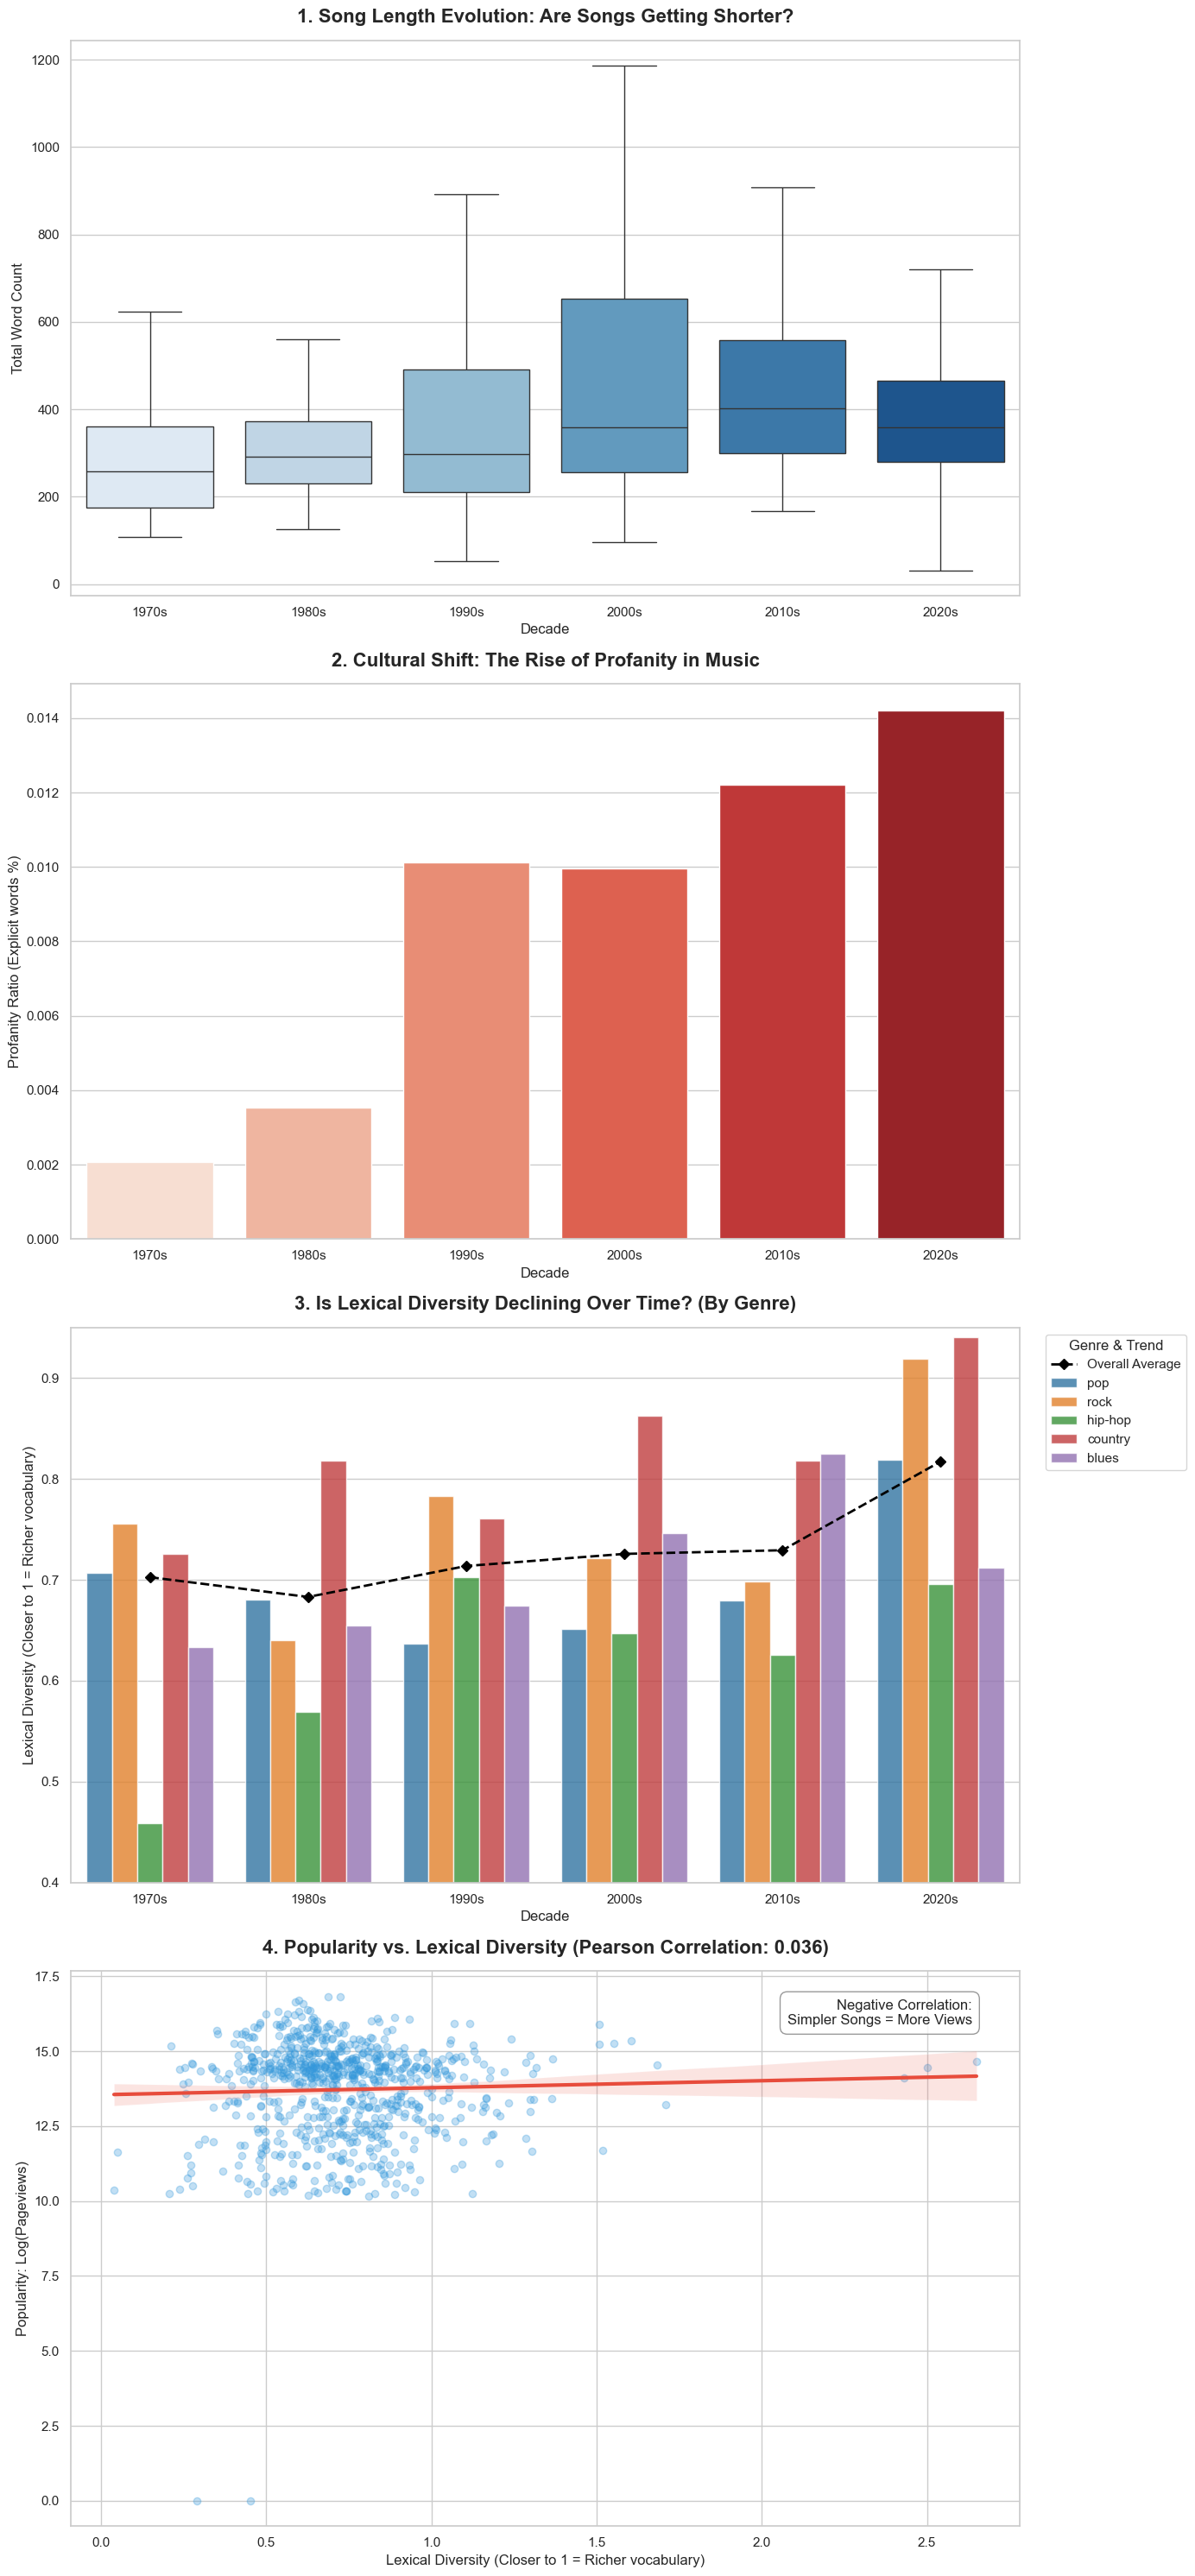

In [ ]:
# 4 גרפים שמראים את השינויים התרבותיים בשירים לאורך העשורים, כולל ניתוח של אורך השיר, שימוש בשפה בוטה, עושר מילולי ופופולריות מול עושר מילולי.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. טעינת הנתונים והכנת העשורים
df = pd.read_csv('final_genius_enriched_songs_by_dacades_patched.csv')

df = df.dropna(subset=['release_year'])
df['decade'] = (df['release_year'] // 10 * 10).astype(int).astype(str) + 's'

valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df = df[df['decade'].isin(valid_decades)]
df['decade'] = pd.Categorical(df['decade'], categories=valid_decades, ordered=True)

# --- התיקון הקריטי: בחירה אוטומטית של ז'אנרים ---
# ניקח את 5 הז'אנרים שמופיעים הכי הרבה בדאטה-סט הנוכחי (כך שזה יעבוד גם לחדש וגם לישן)
top_genres = df['genre'].value_counts().nlargest(5).index.tolist()
df_top = df[df['genre'].isin(top_genres)].copy()

print(f"=== מריץ ניתוח על הז'אנרים: {top_genres} ===")

# 2. הגדרת סגנון הויזואליזציה
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(4, 1, figsize=(14, 30))

# ==========================================
# גרף 1: האם השירים מתקצרים? (Total Word Count)
# ==========================================
sns.boxplot(data=df, x='decade', y='total_word_count', ax=axes[0], palette='Blues', showfliers=False)
axes[0].set_title('1. Song Length Evolution: Are Songs Getting Shorter?', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Total Word Count', fontsize=12)
axes[0].set_xlabel('Decade', fontsize=12)

# ==========================================
# גרף 2: האם השפה נעשתה בוטה יותר? (Profanity Ratio)
# ==========================================
sns.barplot(data=df, x='decade', y='profanity_ratio', ax=axes[1], palette='Reds', errorbar=None)
axes[1].set_title('2. Cultural Shift: The Rise of Profanity in Music', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Profanity Ratio (Explicit words %)', fontsize=12)
axes[1].set_xlabel('Decade', fontsize=12)

# ==========================================
# גרף 3: עושר מילולי לאורך זמן (Barplot קבוצתי)
# ==========================================
# קו המגמה הכללי
overall_means = df.groupby('decade')['unique_ratio_no_repeated_chorus'].mean()
axes[2].plot(range(len(valid_decades)), overall_means.values, color='black', marker='D', linestyle='--', linewidth=2, label='Overall Average', zorder=5)

# עמודות הז'אנרים (שנבחרו אוטומטית)
sns.barplot(data=df_top, x='decade', y='unique_ratio_no_repeated_chorus', hue='genre', 
            ax=axes[2], palette='tab10', errorbar=None, alpha=0.8)

axes[2].set_title('3. Is Lexical Diversity Declining Over Time? (By Genre)', fontsize=16, fontweight='bold', pad=15)
axes[2].set_ylabel('Lexical Diversity (Closer to 1 = Richer vocabulary)', fontsize=12)
axes[2].set_xlabel('Decade', fontsize=12)
axes[2].set_ylim(0.4, 0.95) # שונה מעט לטווח רחב יותר כדי לתפוס את ההיפ-הופ והפופ
axes[2].legend(title='Genre & Trend', bbox_to_anchor=(1.02, 1), loc='upper left')

# ==========================================
# גרף 4: פופולריות מול עושר מילולי 
# ==========================================
df['log_pageviews'] = np.log1p(df['pageviews'])
corr, _ = stats.pearsonr(df['unique_ratio_no_repeated_chorus'].dropna(), df['log_pageviews'].dropna())

sns.regplot(data=df, x='unique_ratio_no_repeated_chorus', y='log_pageviews', ax=axes[3],
            scatter_kws={'alpha':0.3, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c', 'linewidth':3})

axes[3].set_title(f'4. Popularity vs. Lexical Diversity (Pearson Correlation: {corr:.3f})', fontsize=16, fontweight='bold', pad=15)
axes[3].set_xlabel('Lexical Diversity (Closer to 1 = Richer vocabulary)', fontsize=12)
axes[3].set_ylabel('Popularity: Log(Pageviews)', fontsize=12)

axes[3].text(0.95, 0.95, f'Negative Correlation:\nSimpler Songs = More Views', 
             transform=axes[3].transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

In [ ]:
# אורך שירים לפי ז׳אנר לאורך העשורים (חציון)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. טעינת הנתונים והכנת העשורים
df = pd.read_csv('final_genius_enriched_songs_by_dacades_patched.csv') 
df = df.dropna(subset=['release_year'])
df['decade'] = (df['release_year'] // 10 * 10).astype(int).astype(str) + 's'

valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df = df[df['decade'].isin(valid_decades)]
df['decade'] = pd.Categorical(df['decade'], categories=valid_decades, ordered=True)

# בחירת 5 הז'אנרים המובילים
top_genres = df['genre'].value_counts().nlargest(5).index.tolist()
df_top = df[df['genre'].isin(top_genres)].copy()

# 2. בניית הגרף (מבוסס חציון)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid", palette="muted")

# שימוש ב-np.median בתור ה-estimator
sns.pointplot(data=df_top, x='decade', y='total_word_count', hue='genre', 
              estimator=np.median,
              markers='o', linewidth=3, errorbar=None)

# עיצוב וכותרות
plt.title('Are Songs Getting Shorter? Median Word Count by Genre', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=13)
plt.ylabel('Median Word Count per Song', fontsize=13)

# סידור המקרא מחוץ לגרף בצד ימין למעלה
plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')



plt.tight_layout()
plt.show()

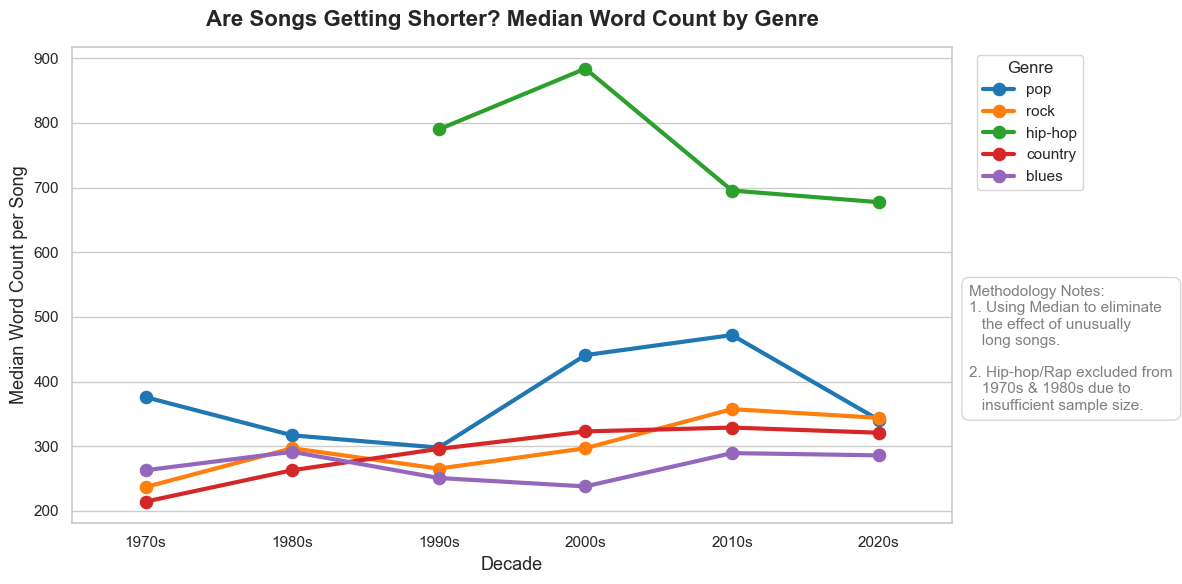

In [6]:
# אורך שירים לפי ז׳אנר לאורך העשורים (חציון) - גרסה נקייה לדו"ח
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. טעינת הנתונים הסופיים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)

df = df.dropna(subset=['release_year'])
df['decade'] = (df['release_year'] // 10 * 10).astype(int).astype(str) + 's'

valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df = df[df['decade'].isin(valid_decades)]
df['decade'] = pd.Categorical(df['decade'], categories=valid_decades, ordered=True)

# בחירת 5 הז'אנרים המובילים
top_genres = df['genre'].value_counts().nlargest(5).index.tolist()
df_top = df[df['genre'].isin(top_genres)].copy()

# סינון ההיפ-הופ/ראפ של שנות ה-70 וה-80 (מניעת סטיית מדגם קטן)
outlier_condition = (df_top['genre'].isin(['hip-hop', 'rap'])) & (df_top['decade'].isin(['1970s', '1980s']))
df_filtered = df_top[~outlier_condition].copy()

# 2. בניית הגרף (גרסה נקייה לדו"ח)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# ציור הגרף (Pointplot מבוסס חציון)
sns.pointplot(data=df_filtered, x='decade', y='total_word_count', hue='genre', 
              estimator=np.median, markers='o', linewidth=3, errorbar=None, palette='tab10')

# עיצוב וכותרות
plt.title('Are Songs Getting Shorter? Median Word Count by Genre', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=13)
plt.ylabel('Median Word Count per Song', fontsize=13)

# סידור המקרא בצד (כדי שלא יסתיר את הגרף)
plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')

# הוספת הערות מתודולוגיות רלוונטיות
plt.text(1.02, 0.5, "Methodology Notes:\n1. Using Median to eliminate\n   the effect of unusually\n   long songs.\n\n2. Hip-hop/Rap excluded from\n   1970s & 1980s due to\n   insufficient sample size.", 
         transform=plt.gca().transAxes, fontsize=11, color='gray',
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

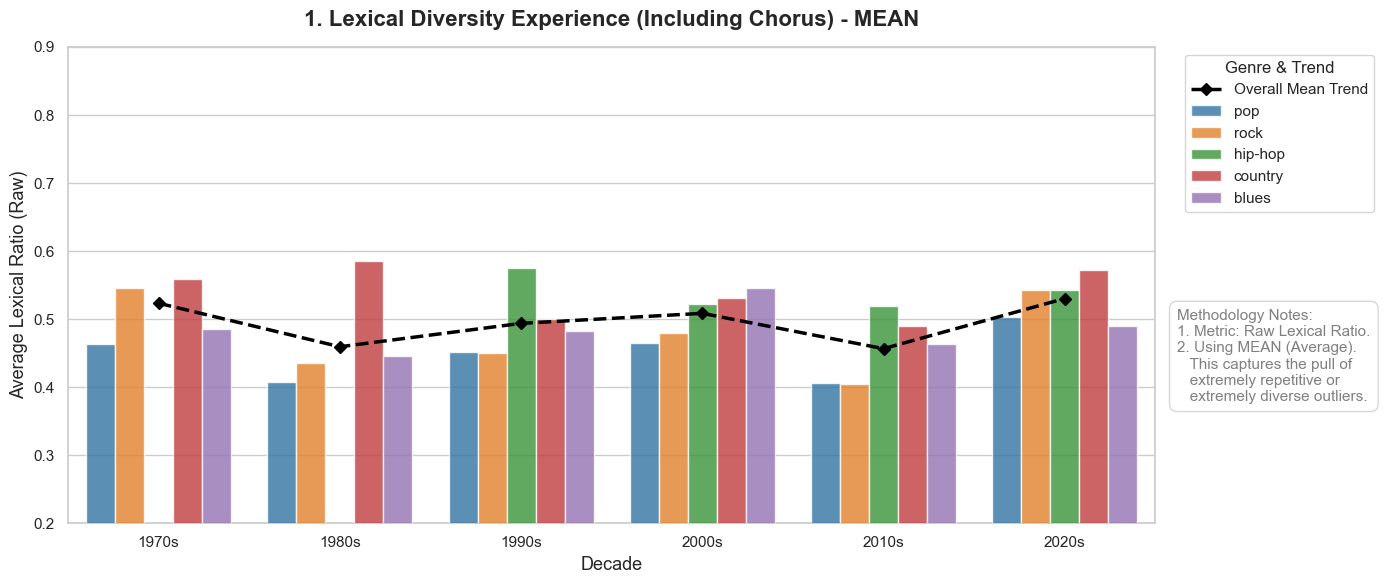

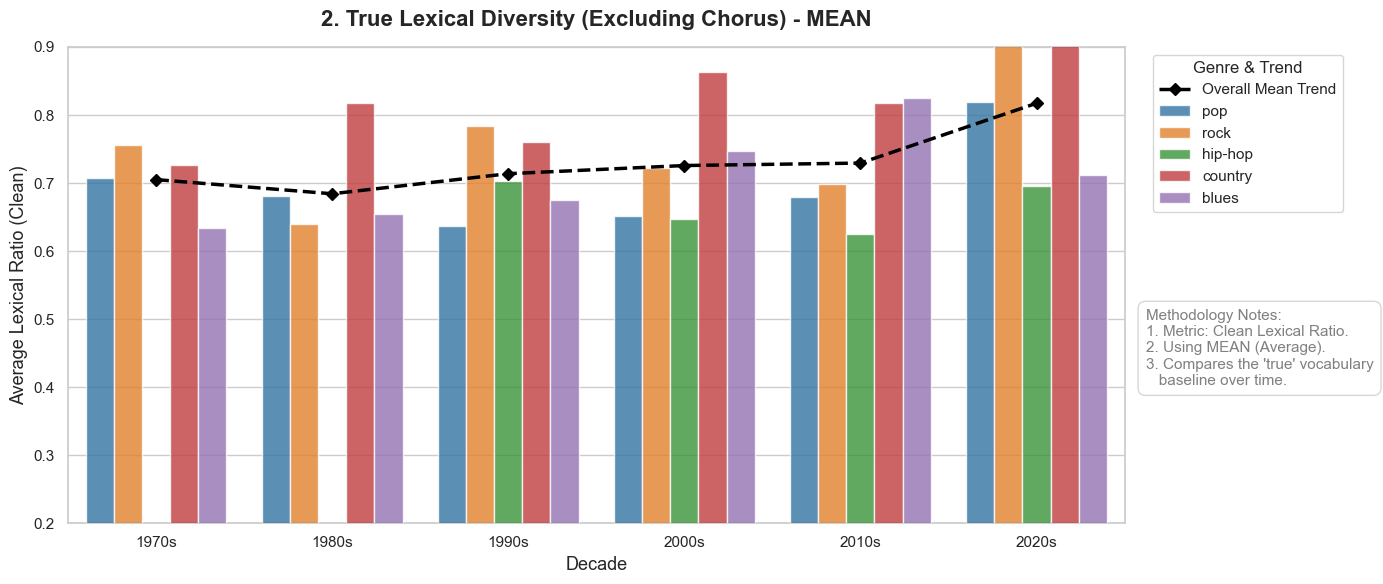

In [ ]:
# מדד עושר לשוני לז׳אנר לעשור עם ובלי חזרת פזמונים
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. טעינת הנתונים הסופיים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)

df = df.dropna(subset=['release_year'])
df['decade'] = (df['release_year'] // 10 * 10).astype(int).astype(str) + 's'

valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df = df[df['decade'].isin(valid_decades)]
df['decade'] = pd.Categorical(df['decade'], categories=valid_decades, ordered=True)

# בחירת 5 הז'אנרים המובילים
top_genres = df['genre'].value_counts().nlargest(5).index.tolist()
df_top = df[df['genre'].isin(top_genres)].copy()

# סינון ההיפ-הופ/ראפ של שנות ה-70 וה-80
outlier_condition = (df_top['genre'].isin(['hip-hop', 'rap'])) & (df_top['decade'].isin(['1970s', '1980s']))
df_filtered = df_top[~outlier_condition].copy()

sns.set_theme(style="whitegrid")

# ==========================================
# גרף 1: המדד הגולמי (כולל פזמונים) - מבוסס ממוצע
# ==========================================
plt.figure(figsize=(14, 6))

overall_means_raw = df_filtered.groupby('decade', observed=False)['special_words_ratio'].mean()

plt.plot(range(len(valid_decades)), overall_means_raw.values, color='black', marker='D', 
         linestyle='--', linewidth=2.5, label='Overall Mean Trend', zorder=5)

sns.barplot(data=df_filtered, x='decade', y='special_words_ratio', hue='genre', 
            estimator=np.mean, palette='tab10', errorbar=None, alpha=0.8, zorder=3)

plt.title('1. Lexical Diversity Experience (Including Chorus) - MEAN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=13)
plt.ylabel('Average Lexical Ratio (Raw)', fontsize=13)
plt.ylim(0.2, 0.9)
plt.legend(title='Genre & Trend', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.text(1.02, 0.45, "Methodology Notes:\n1. Metric: Raw Lexical Ratio.\n2. Using MEAN (Average).\n   This captures the pull of\n   extremely repetitive or\n   extremely diverse outliers.", 
         transform=plt.gca().transAxes, fontsize=11, color='gray', verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

# ==========================================
# גרף 2: המדד הנקי (ללא פזמונים) - מבוסס ממוצע
# ==========================================
plt.figure(figsize=(14, 6))

overall_means_clean = df_filtered.groupby('decade', observed=False)['unique_ratio_no_repeated_chorus'].mean()

plt.plot(range(len(valid_decades)), overall_means_clean.values, color='black', marker='D', 
         linestyle='--', linewidth=2.5, label='Overall Mean Trend', zorder=5)

sns.barplot(data=df_filtered, x='decade', y='unique_ratio_no_repeated_chorus', hue='genre', 
            estimator=np.mean, palette='tab10', errorbar=None, alpha=0.8, zorder=3)

plt.title('2. True Lexical Diversity (Excluding Chorus) - MEAN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=13)
plt.ylabel('Average Lexical Ratio (Clean)', fontsize=13)
plt.ylim(0.2, 0.9)
plt.legend(title='Genre & Trend', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.text(1.02, 0.45, "Methodology Notes:\n1. Metric: Clean Lexical Ratio.\n2. Using MEAN (Average).\n3. Compares the 'true' vocabulary\n   baseline over time.", 
         transform=plt.gca().transAxes, fontsize=11, color='gray', verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

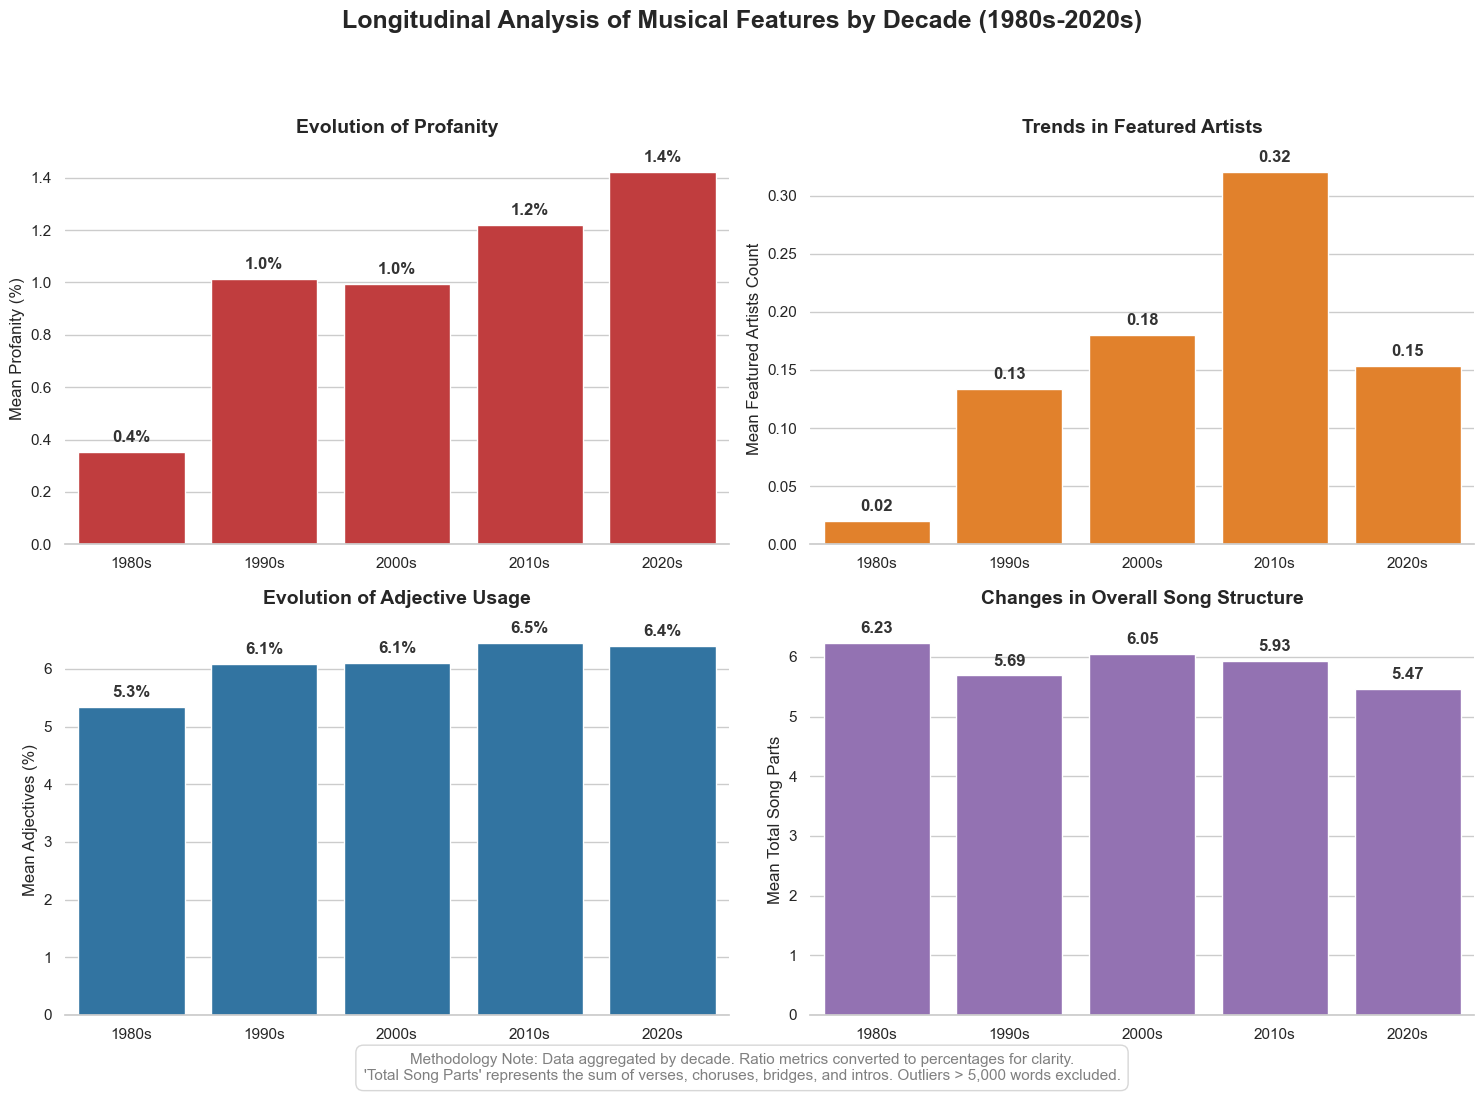

In [ ]:
# טרנדים שונים לעשורים
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. טעינת הנתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)

# 2. ניקוי וסינון
df_trends = df.dropna(subset=['release_year']).copy()

# חיתוך תצפיות חריגות (שירים מעל 5000 מילים)
df_trends = df_trends[df_trends['total_word_count'] < 5000]

# חלוקה לעשורים
df_trends['decade'] = (df_trends['release_year'] // 10 * 10).astype(int).astype(str) + 's'
valid_decades = ['1980s', '1990s', '2000s', '2010s', '2020s']
df_trends = df_trends[df_trends['decade'].isin(valid_decades)]

# סידור כרונולוגי
df_trends['decade'] = pd.Categorical(df_trends['decade'], categories=valid_decades, ordered=True)

# 3. הנדסת מאפיינים לגרפים
# המרה לאחוזים
df_trends['profanity_percentage'] = df_trends['profanity_ratio'] * 100
df_trends['adjectives_percentage'] = df_trends['adjectives_ratio'] * 100

# שילוב כל חלקי השיר (בתים + פזמונים + גשרים + פתיח) למשתנה אחד. 
# מילוי NaN ב-0 כדי למנוע שגיאות חיבור
parts = ['count_verse', 'count_chorus', 'count_bridge', 'count_intro']
for p in parts:
    if p in df_trends.columns:
        df_trends[p] = df_trends[p].fillna(0)

# סכימה של המבנה המלא
df_trends['total_structural_parts'] = df_trends['count_verse'] + df_trends['count_chorus'] + df_trends['count_bridge'] + df_trends['count_intro']

# 4. הכנת רשת הגרפים (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.set_theme(style="whitegrid")

# פונקציית עזר לציור
def plot_decade_bar(ax, y_col, title, color, ylabel, is_percentage=False):
    sns.barplot(data=df_trends, x='decade', y=y_col, ax=ax, color=color, errorbar=None)
    
    # הוספת הערך המספרי מעל כל עמודה
    for p in ax.patches:
        height = p.get_height()
        label_text = f'{height:.1f}%' if is_percentage else f'{height:.2f}'
        ax.annotate(label_text, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold', color='#333333')
        
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('')
    sns.despine(ax=ax, left=True)

# גרף 1: אחוזי בוטות
plot_decade_bar(axes[0, 0], 'profanity_percentage', 'Evolution of Profanity', '#d62728', 'Mean Profanity (%)', is_percentage=True)

# גרף 2: אמנים אורחים
plot_decade_bar(axes[0, 1], 'featured_artists_count', 'Trends in Featured Artists', '#ff7f0e', 'Mean Featured Artists Count')

# גרף 3: אחוזי תארים
plot_decade_bar(axes[1, 0], 'adjectives_percentage', 'Evolution of Adjective Usage', '#1f77b4', 'Mean Adjectives (%)', is_percentage=True)

# גרף 4: המבנה הכולל של השיר
plot_decade_bar(axes[1, 1], 'total_structural_parts', 'Changes in Overall Song Structure', '#9467bd', 'Mean Total Song Parts')

# כותרות והערות
plt.suptitle('Longitudinal Analysis of Musical Features by Decade (1980s-2020s)', fontsize=18, fontweight='bold', y=1.05)

plt.figtext(0.5, -0.02, "Methodology Note: Data aggregated by decade. Ratio metrics converted to percentages for clarity.\n'Total Song Parts' represents the sum of verses, choruses, bridges, and intros. Outliers > 5,000 words excluded.", 
            ha="center", fontsize=11, color='gray', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

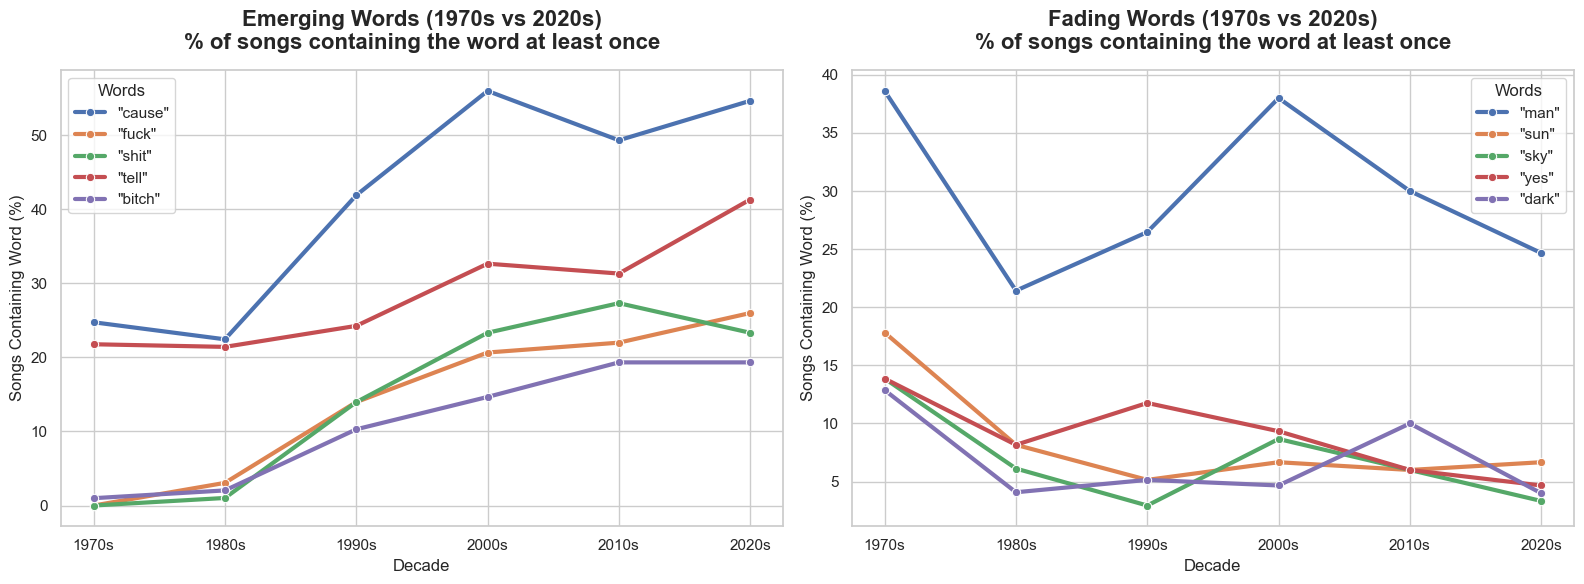

Emerging Words Found: ['cause', 'fuck', 'shit', 'tell', 'bitch']
Fading Words Found: ['man', 'sun', 'sky', 'yes', 'dark']


In [ ]:
# עלייה ונפילה של מילים לאורך העשורים (NLP) לפי אחוז השירים שבהם מופיעה המילה לפחות פעם אחת
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 1. טעינת הנתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)
df_nlp = df.dropna(subset=['lyrics', 'release_year']).copy()

df_nlp['decade'] = (df_nlp['release_year'] // 10 * 10).astype(int).astype(str) + 's'
valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df_nlp = df_nlp[df_nlp['decade'].isin(valid_decades)]

# 2. ניקוי טקסט מקדים (Regex) 
df_nlp['lyrics_clean'] = df_nlp['lyrics'].str.replace(r'\[.*?\]', ' ', regex=True)

# 3. הכנת מילון "מילות העצירה" המורחב
custom_fillers = [
    'na', 'la', 'oh', 'ooh', 'ah', 'yeah', 'mm', 'uh', 'baby', 
    'yo', 'doo', 'da', 'bum', 'woo', 'hey', 'ha', 'ayy', 'wan', 'gon', 'got',
    'chorus', 'verse', 'intro', 'outro', 'bridge', 'pre' 
]
all_stop_words = list(ENGLISH_STOP_WORDS) + custom_fillers

# 4. הפעלת מודל שפה
vectorizer = CountVectorizer(stop_words=all_stop_words, min_df=0.05, max_df=0.5, binary=True)

df_compare = df_nlp[df_nlp['decade'].isin(['1970s', '2020s'])]
X_compare = vectorizer.fit_transform(df_compare['lyrics_clean'])
words = vectorizer.get_feature_names_out()

df_words_compare = pd.DataFrame(X_compare.toarray(), columns=words)
df_words_compare['decade'] = df_compare['decade'].values

# חישוב אחוז השירים
doc_freq = df_words_compare.groupby('decade').mean() * 100
diff = doc_freq.loc['2020s'] - doc_freq.loc['1970s']

emerging_words = diff.nlargest(5).index.tolist() #כמות המילים בתוצאה הסופית
dying_words = diff.nsmallest(5).index.tolist()

# 5. הפקת הנתונים המלאים
target_words = emerging_words + dying_words
vec_full = CountVectorizer(vocabulary=target_words, binary=True)
X_full = vec_full.fit_transform(df_nlp['lyrics_clean'])

df_full_words = pd.DataFrame(X_full.toarray(), columns=target_words)
df_full_words['decade'] = df_nlp['decade'].reset_index(drop=True)

full_doc_freq = df_full_words.groupby('decade').mean() * 100

# 6. ויזואליזציה (עם שליטה במיקום המקרא)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# הוספת פרמטר legend_loc לשליטה במיקום לכל גרף בנפרד
def plot_word_trends(ax, word_list, title, legend_loc):
    for word in word_list:
        sns.lineplot(x=valid_decades, y=full_doc_freq[word].loc[valid_decades], 
                     ax=ax, marker='o', linewidth=3, label=f'"{word}"')
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Songs Containing Word (%)', fontsize=12)
    ax.set_xlabel('Decade', fontsize=12)
    
    # שימוש בפרמטר המיקום
    if legend_loc == 'outside':
        # מקרא מחוץ לגרף מצד ימין (אם תרצה למנוע הסתרה לחלוטין)
        ax.legend(title='Words', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        # מקרא במיקום רגיל לפי ההגדרה
        ax.legend(title='Words', loc=legend_loc)

# ציור הגרף השמאלי - מקרא בצד שמאל למעלה (כמו קודם)
plot_word_trends(axes[0], emerging_words, 'Emerging Words (1970s vs 2020s)\n% of songs containing the word at least once', 'upper left')

# ציור הגרף הימני - מקרא בצד ימין למעלה כדי לא להסתיר את תחילת הקווים
plot_word_trends(axes[1], dying_words, 'Fading Words (1970s vs 2020s)\n% of songs containing the word at least once', 'upper right')

plt.tight_layout()
plt.show()

print("Emerging Words Found:", emerging_words)
print("Fading Words Found:", dying_words)

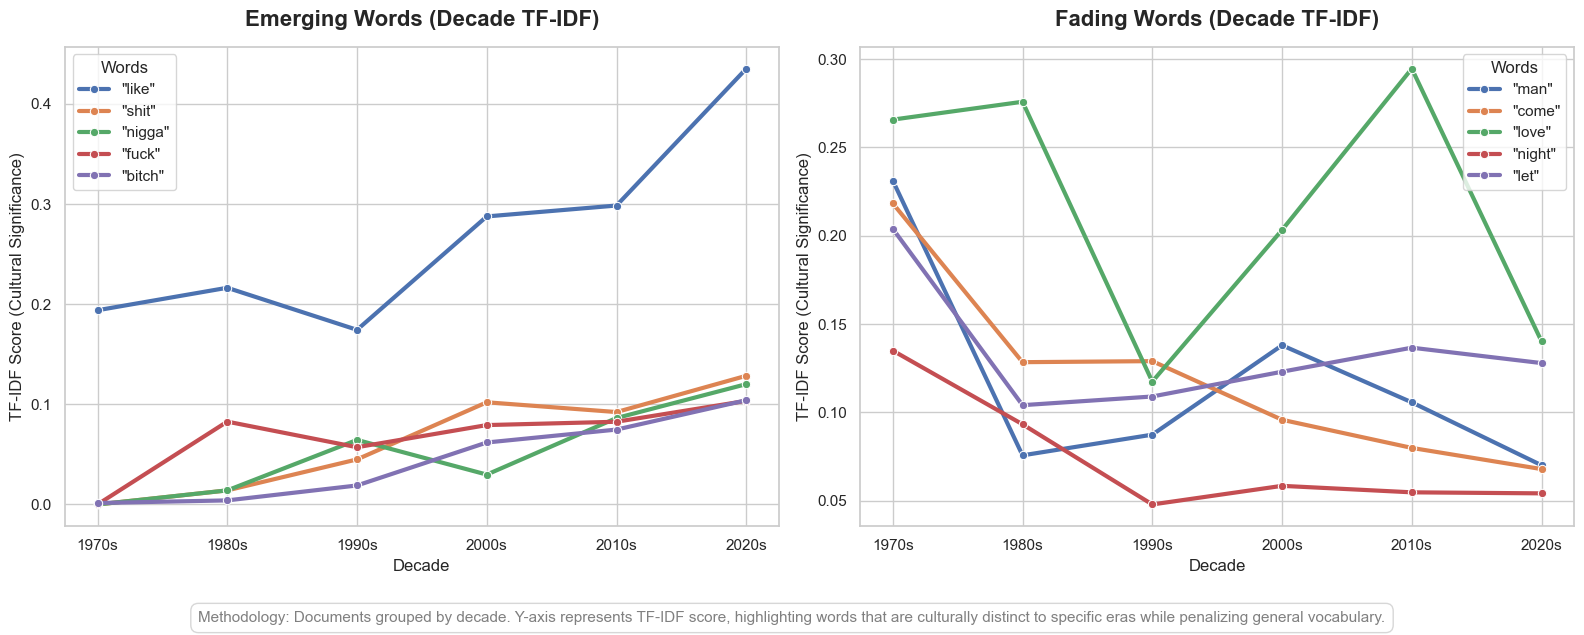

Top Emerging (TF-IDF): ['like', 'shit', 'nigga', 'fuck', 'bitch']
Top Fading (TF-IDF): ['man', 'come', 'love', 'night', 'let']


In [ ]:
#עלייה ונפילה של מילים לאורך העשורים (NLP) לפי מודל TF-IDF (מילות מפתח ייחודיות לעשור)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 1. טעינה וניקוי
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)
df_nlp = df.dropna(subset=['lyrics', 'release_year']).copy()

df_nlp['decade'] = (df_nlp['release_year'] // 10 * 10).astype(int).astype(str) + 's'
valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df_nlp = df_nlp[df_nlp['decade'].isin(valid_decades)]

# ניקוי סוגריים מרובעים (Regex) כמו שעשינו קודם
df_nlp['lyrics_clean'] = df_nlp['lyrics'].str.replace(r'\[.*?\]', ' ', regex=True)

# 2. הפיכת כל עשור ל"מסמך ענק" אחד
# הפקודה הזו מחברת את כל השירים של אותו עשור למחרוזת טקסט ארוכה אחת
df_decades = df_nlp.groupby('decade')['lyrics_clean'].apply(lambda x: ' '.join(x)).reset_index()

# 3. הכנת מילון מילות הפילר
custom_fillers = [
    'na', 'la', 'oh', 'ooh', 'ah', 'yeah', 'mm', 'uh', 'baby','bennie',
    'yo', 'doo', 'da', 'bum', 'woo', 'hey', 'ha', 'ayy', 'wan', 'gon', 'got',
    'chorus', 'verse', 'intro', 'outro', 'bridge', 'pre'
]
all_stop_words = list(ENGLISH_STOP_WORDS) + custom_fillers

# 4. הפעלת מודל TF-IDF
# האלגוריתם אוטומטית יוריד משקל ממילים שמופיעות בכל 6 העשורים, ויעלה מילים ייחודיות
vectorizer = TfidfVectorizer(stop_words=all_stop_words)
tfidf_matrix = vectorizer.fit_transform(df_decades['lyrics_clean'])
words = vectorizer.get_feature_names_out()

# הפיכת התוצאה לדאטה-פריים נוח לקריאה
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=words)
df_tfidf.index = df_decades['decade']

# 5. חישוב השינוי בטביעת האצבע הלקסיקלית (2020s פחות 1970s)
diff = df_tfidf.loc['2020s'] - df_tfidf.loc['1970s']

# מילים שזינקו בייחודיות שלהן
emerging_words = diff.nlargest(5).index.tolist()
# מילים שהתרסקו בייחודיות שלהן
dying_words = diff.nsmallest(5).index.tolist()

# 6. ציור הגרפים
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

def plot_tfidf_trends(ax, word_list, title, legend_loc):
    for word in word_list:
        # מציירים את ציון ה-TF-IDF לאורך העשורים
        sns.lineplot(x=valid_decades, y=df_tfidf[word].loc[valid_decades], 
                     ax=ax, marker='o', linewidth=3, label=f'"{word}"')
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('TF-IDF Score (Cultural Significance)', fontsize=12)
    ax.set_xlabel('Decade', fontsize=12)
    ax.legend(title='Words', loc=legend_loc)

# ציור הגרף השמאלי - מקרא למעלה משמאל
plot_tfidf_trends(axes[0], emerging_words, 'Emerging Words (Decade TF-IDF)', 'upper left')

# ציור הגרף הימני - מקרא למעלה מימין שלא יסתיר
plot_tfidf_trends(axes[1], dying_words, 'Fading Words (Decade TF-IDF)', 'upper right')

# הערה מתודולוגית לתחתית הגרף בדו"ח
plt.figtext(0.5, -0.05, "Methodology: Documents grouped by decade. Y-axis represents TF-IDF score, highlighting words that are culturally distinct to specific eras while penalizing general vocabulary.", 
            ha="center", fontsize=11, color='gray', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

print("Top Emerging (TF-IDF):", emerging_words)
print("Top Fading (TF-IDF):", dying_words)

$$\text{TF-IDF Score} = \left( \frac{\text{Count of word in the decade}}{\text{Total words in the decade}} \right) \cdot \log \left( \frac{\text{Total number of decades}}{\text{Number of decades containing the word}} \right)$$

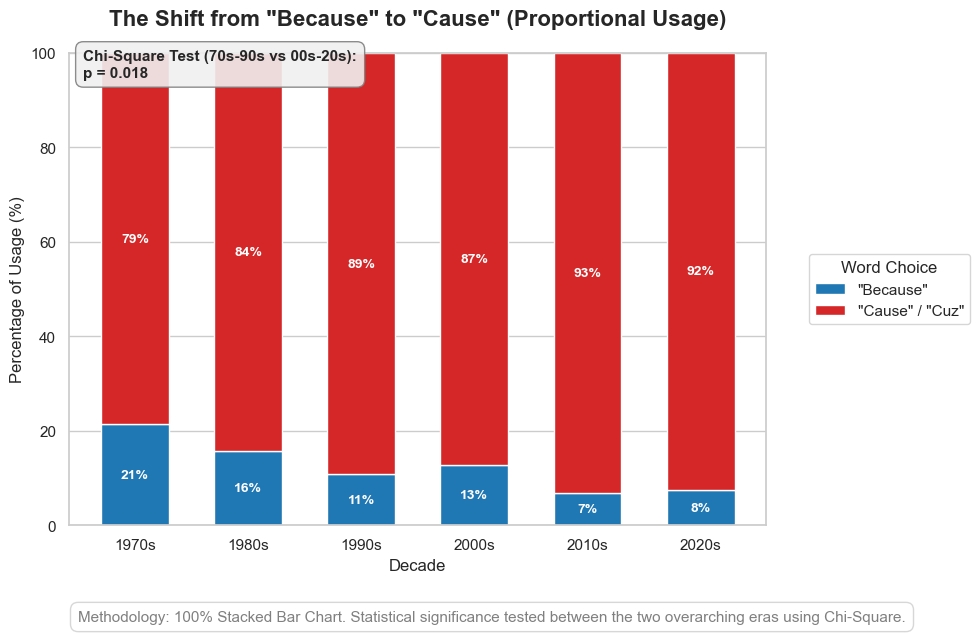

Chi-Square P-Value: 0.018282482342007585

Era Counts Table (For your reference):
                   because_count  cause_count
era                                          
New Era (00s-20s)             74          710
Old Era (70s-90s)             52          311


In [ ]:
# שימוש במילים because ו-cause לאורך העשורים (NLP) לפי אחוז השירים שבהם מופיעה המילה לפחות פעם אחת
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from scipy.stats import chi2_contingency

# 1. טעינת נתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)
df_nlp = df.dropna(subset=['lyrics', 'release_year']).copy()

df_nlp['decade'] = (df_nlp['release_year'] // 10 * 10).astype(int).astype(str) + 's'
valid_decades = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
df_nlp = df_nlp[df_nlp['decade'].isin(valid_decades)]

# 2. ספירת מילים
def count_word(text, word_pattern):
    return len(re.findall(word_pattern, str(text).lower()))

df_nlp['because_count'] = df_nlp['lyrics'].apply(lambda x: count_word(x, r'\bbecause\b'))
df_nlp['cause_count'] = df_nlp['lyrics'].apply(lambda x: count_word(x, r"\b'?cause\b|\bcuz\b|\bcos\b"))

# 3. קיבוץ וחישוב אחוזים לגרף (לפי כל עשור)
trend_df = df_nlp.groupby('decade')[['because_count', 'cause_count']].sum()
trend_df['total_family'] = trend_df['because_count'] + trend_df['cause_count']
trend_df['cause_pct'] = (trend_df['cause_count'] / trend_df['total_family']) * 100
trend_df['because_pct'] = (trend_df['because_count'] / trend_df['total_family']) * 100
trend_df = trend_df.reindex(valid_decades)

# 4. ביצוע מבחן חי-בריבוע בין שתי התקופות הגדולות
# הגדרת התקופות
df_nlp['era'] = np.where(df_nlp['decade'].isin(['1970s', '1980s', '1990s']), 'Old Era (70s-90s)', 'New Era (00s-20s)')

# יצירת טבלת התדירויות של המילים המוחלטות (חובה לחישוב חי-בריבוע)
era_counts = df_nlp.groupby('era')[['because_count', 'cause_count']].sum()
chi2, p_value, dof, expected = chi2_contingency(era_counts)

# עיצוב הטקסט של ה-P-value לתצוגה על הגרף
if p_value < 0.001:
    p_text = "p < 0.001 ***"
else:
    p_text = f"p = {p_value:.3f}"

# 5. ציור גרף עמודות 100%
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

x = np.arange(len(trend_df.index))
width = 0.6 

# ציור העמודות 
plt.bar(x, trend_df['because_pct'], width, label='"Because"', color='#1f77b4', edgecolor='white', linewidth=1)
plt.bar(x, trend_df['cause_pct'], width, bottom=trend_df['because_pct'], label='"Cause" / "Cuz"', color='#d62728', edgecolor='white', linewidth=1)

# טקסט בתוך העמודות
for i, (bec_val, cau_val) in enumerate(zip(trend_df['because_pct'], trend_df['cause_pct'])):
    if bec_val > 5:
        plt.text(i, bec_val / 2, f'{bec_val:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    if cau_val > 5:
        plt.text(i, bec_val + (cau_val / 2), f'{cau_val:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# עיצוב והוספת תיבת המובהקות הסטטיסטית (P-value Box)
plt.title('The Shift from "Because" to "Cause" (Proportional Usage)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Percentage of Usage (%)', fontsize=12)
plt.xlabel('Decade', fontsize=12)
plt.xticks(x, trend_df.index, fontsize=11)
plt.ylim(0, 100) 
plt.legend(title='Word Choice', loc='center left', bbox_to_anchor=(1.05, 0.5))

# שתילת קופסת המובהקות בפינה השמאלית העליונה
plt.text(0.02, 0.95, f'Chi-Square Test (70s-90s vs 00s-20s):\n{p_text}', 
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold', 
         bbox=dict(facecolor='#f0f0f0', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.figtext(0.5, -0.05, "Methodology: 100% Stacked Bar Chart. Statistical significance tested between the two overarching eras using Chi-Square.", 
            ha="center", fontsize=11, color='gray', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

plt.tight_layout()
plt.show()

# הדפסה לבדיקת שפיות של החישוב
print(f"Chi-Square P-Value: {p_value}")
print("\nEra Counts Table (For your reference):")
print(era_counts)

In [ ]:
# כמות השירים לפי שנה, לשנים האחרונות (2018-2026)
import pandas as pd

# טעינת הנתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df = pd.read_csv(file_name)
df_nlp = df.dropna(subset=['lyrics', 'release_year']).copy()

# ספירת שירים לפי שנה, לשנים האחרונות
recent_years = df_nlp[df_nlp['release_year'] >= 2018]['release_year'].value_counts().sort_index()

print("Song Count by Year (Recent):")
print(recent_years)

Song Count by Year (Recent):
release_year
2018    19
2019    12
2020    25
2021    20
2022    13
2023    13
2024    48
2025    24
2026     7
Name: count, dtype: int64


/var/folders/gq/3m6xxzy938l2yt6bdfz8hksh0000gn/T/ipykernel_18766/4240226957.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_recent, x='llm_era', y='ai_density', palette=['#55a868', '#c44e52'], errorbar='se')


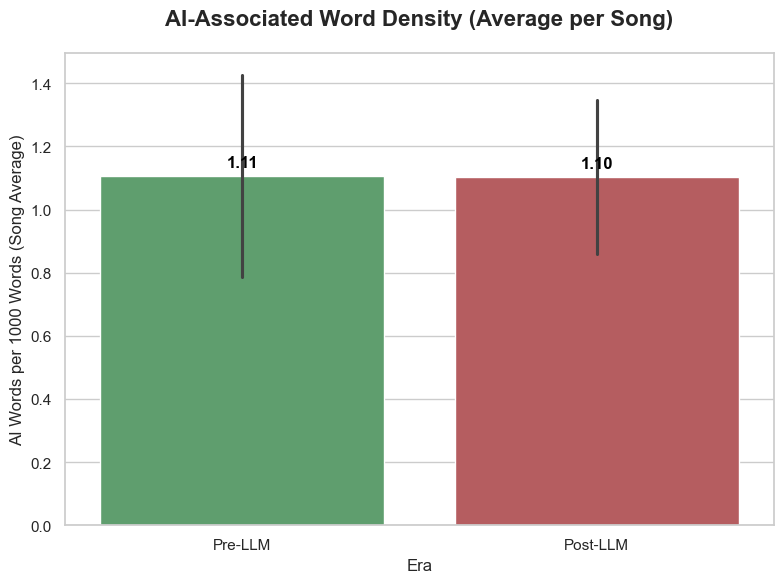

In [ ]:
# עלייה של מילים הקשורות ל-AI לאורך השנים האחרונות (2018-2026) - צפיפות מילים לכל 1000 מילים
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. טעינת הנתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df_songs = pd.read_csv(file_name)
df_songs = df_songs.dropna(subset=['lyrics', 'release_year', 'total_word_count']).copy()
df_songs = df_songs[df_songs['total_word_count'] > 0] # מניעת חלוקה באפס

# 2. הכנה לתקופות
df_recent = df_songs[df_songs['release_year'] >= 2018].copy()
df_recent['llm_era'] = np.where(df_recent['release_year'] <= 2022, 'Pre-LLM', 'Post-LLM')

# 3. הכנת מילון המילים (130 מילים)
df_ai_words = pd.read_excel('130ai-words.xlsx')
all_words = df_ai_words['Word'].str.lower().tolist()
# יצירת תבנית חיפוש אחת לכל הרשימה
all_pattern = r'\b(?:' + '|'.join([re.escape(str(w).strip()) for w in all_words if pd.notna(w)]) + r')\b'

# 4. חישוב צפיפות (Density) לכל שיר בנפרד
def calculate_density(row):
    text = str(row['lyrics']).lower()
    matches = len(re.findall(all_pattern, text))
    return (matches / row['total_word_count']) * 1000 # צפיפות לכל 1000 מילים

df_recent['ai_density'] = df_recent.apply(calculate_density, axis=1)

# 5. ויזואליזציה פשוטה וברורה
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# שימוש ב-barplot עם CI (רווח סמך) שמראה את הדיוק של הממוצע
ax = sns.barplot(data=df_recent, x='llm_era', y='ai_density', palette=['#55a868', '#c44e52'], errorbar='se')

plt.title('AI-Associated Word Density (Average per Song)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('AI Words per 1000 Words (Song Average)', fontsize=12)
plt.xlabel('Era', fontsize=12)

# הוספת הערכים הממוצעים על הגרף
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

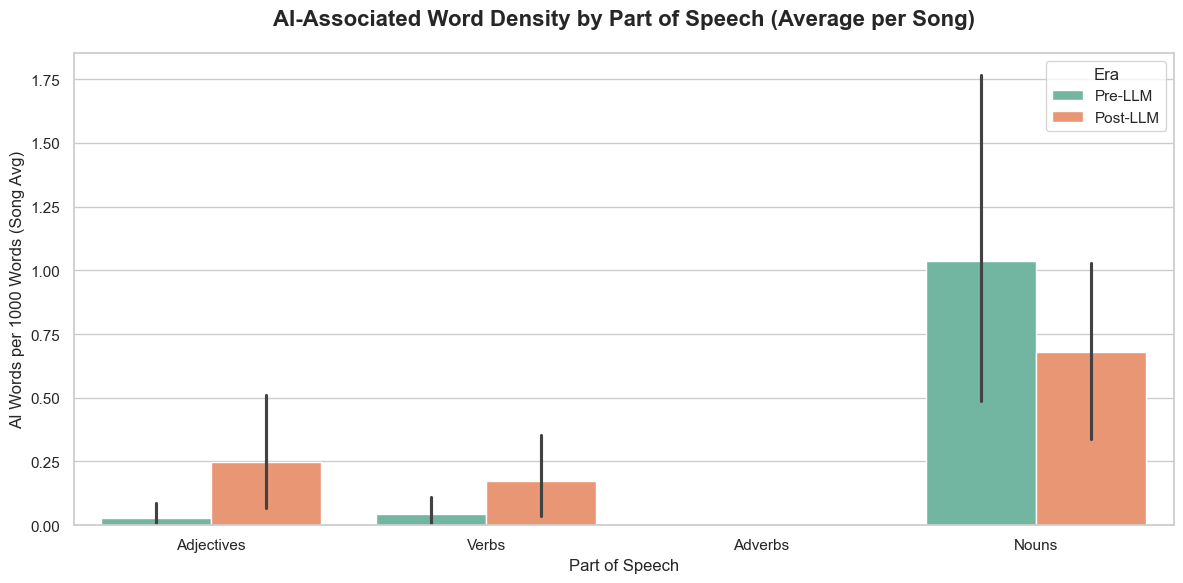

POS       Adjectives  Adverbs     Nouns     Verbs
llm_era                                          
Post-LLM    0.249553      0.0  0.679697  0.173112
Pre-LLM     0.028518      0.0  1.035340  0.042388


In [ ]:
# עלייה של מילים הקשורות ל-AI לאורך השנים האחרונות (2018-2026) - צפיפות מילים לכל 1000 מילים לפי סוג המילה
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. טעינת הנתונים
file_name = 'final_genius_enriched_songs_by_dacades_patched.csv'
df_songs = pd.read_csv(file_name)
df_songs = df_songs.dropna(subset=['lyrics', 'release_year', 'total_word_count']).copy()
df_songs = df_songs[df_songs['total_word_count'] > 0]

df_recent = df_songs[df_songs['release_year'] >= 2018].copy()
df_recent['llm_era'] = np.where(df_recent['release_year'] <= 2022, 'Pre-LLM', 'Post-LLM')

# 2. הכנת מילון המילים המפולח
df_ai_words = pd.read_excel('130ai-words.xlsx')

def get_pat(pos):
    words = df_ai_words[df_ai_words['POS'] == pos]['Word'].str.lower().tolist()
    if not words: return r'(?!)'
    return r'\b(?:' + '|'.join([re.escape(str(w).strip()) for w in words]) + r')\b'

patterns = {
    'Adjectives': get_pat('Adjectives'),
    'Verbs': get_pat('Verbs'),
    'Adverbs': get_pat('Adverbs'),
    'Nouns': get_pat('Nouns')
}

# 3. חישוב צפיפות (Density) לכל שיר לכל סוג מילה
def calculate_density(text, pattern, total_words):
    matches = len(re.findall(pattern, str(text).lower()))
    return (matches / total_words) * 1000 # לכל 1000 מילים

for pos, pat in patterns.items():
    df_recent[f'{pos}_density'] = df_recent.apply(lambda row: calculate_density(row['lyrics'], pat, row['total_word_count']), axis=1)

# 4. קיבוץ ועיבוד הנתונים לגרף
melted_df = df_recent.melt(
    id_vars=['llm_era'], 
    value_vars=['Adjectives_density', 'Verbs_density', 'Adverbs_density', 'Nouns_density'],
    var_name='POS', value_name='Density'
)

# ניקוי שמות לצורך הגרף
melted_df['POS'] = melted_df['POS'].str.replace('_density', '')

# 5. ציור הגרף
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=melted_df, x='POS', y='Density', hue='llm_era', palette='Set2')

plt.title('AI-Associated Word Density by Part of Speech (Average per Song)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('AI Words per 1000 Words (Song Avg)', fontsize=12)
plt.xlabel('Part of Speech', fontsize=12)
plt.legend(title='Era')

plt.tight_layout()
plt.show()

# הדפסת נתונים לבדיקה
print(melted_df.groupby(['llm_era', 'POS'])['Density'].mean().unstack())

Observed Diff Adjectives: 0.2210
Observed Diff Verbs: 0.1307


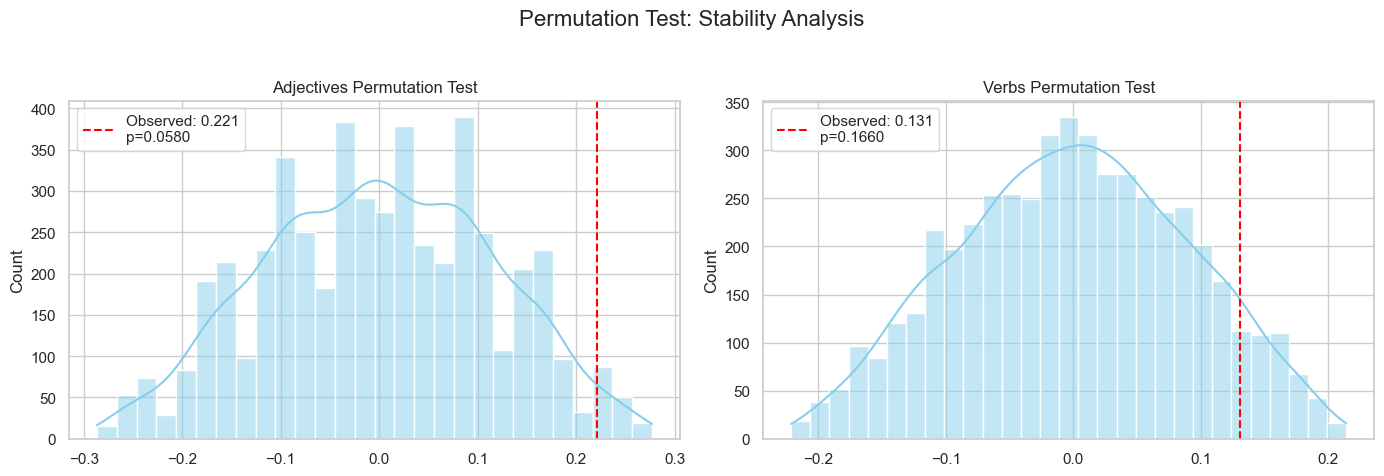

P-value Adjectives: 0.0580
P-value Verbs: 0.1660


In [ ]:
# עלייה של מילים הקשורות ל-AI לאורך השנים האחרונות (2018-2026) - מבחן פרמוטציות
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# קיבוע ה-Seed להבטחת תוצאות זהות בכל הרצה
#np.random.seed(42)

# 1. טעינת נתונים
df_songs = pd.read_csv('final_genius_enriched_songs_by_dacades_patched.csv')
df_ai_words = pd.read_excel('130ai-words.xlsx')

# 2. סינון וניקוי נתונים
# נשמור רק שירים מ-2018 ואילך, ונסיר שירים קצרים מדי (פחות מ-30 מילים) למניעת רעש סטטיסטי
df_recent = df_songs[(df_songs['release_year'] >= 2018) & (df_songs['total_word_count'] > 30)].copy()

# הגדרת תקופות
df_recent['llm_era'] = np.where(df_recent['release_year'] <= 2022, 'Pre-LLM', 'Post-LLM')

# 3. הכנת תבניות חיפוש למילים
def get_pat(pos):
    words = df_ai_words[df_ai_words['POS'] == pos]['Word'].str.lower().tolist()
    return r'\b(?:' + '|'.join([re.escape(str(w).strip()) for w in words]) + r')\b'

adj_pat = get_pat('Adjectives')
verb_pat = get_pat('Verbs')

# 4. חישוב צפיפות (Density) לכל שיר בנפרד
# Density = (מספר מילות AI / סך כל המילים בשיר) * 1000
def calculate_density(text, pattern, total_words):
    count = len(re.findall(pattern, str(text).lower()))
    return (count / total_words) * 1000

df_recent['adj_density'] = df_recent.apply(lambda row: calculate_density(row['lyrics'], adj_pat, row['total_word_count']), axis=1)
df_recent['verb_density'] = df_recent.apply(lambda row: calculate_density(row['lyrics'], verb_pat, row['total_word_count']), axis=1)

# 5. חישוב הערך הנצפה (Observed Difference) - חד פעמי וקבוע
obs_diff_adj = df_recent[df_recent['llm_era'] == 'Post-LLM']['adj_density'].mean() - \
               df_recent[df_recent['llm_era'] == 'Pre-LLM']['adj_density'].mean()

obs_diff_verb = df_recent[df_recent['llm_era'] == 'Post-LLM']['verb_density'].mean() - \
                df_recent[df_recent['llm_era'] == 'Pre-LLM']['verb_density'].mean()

print(f"Observed Diff Adjectives: {obs_diff_adj:.4f}")
print(f"Observed Diff Verbs: {obs_diff_verb:.4f}")

# 6. מבחן פרמוטציות (Permutation Test)
def run_robust_permutation(data, col, observed_val, n=5000):
    perm_diffs = []
    labels_original = data['llm_era'].values.copy()
    vals = data[col].values
    
    for _ in range(n):
        labels_shuffled = labels_original.copy()
        np.random.shuffle(labels_shuffled)
        
        # חישוב הפרש במקרה של ערבוב
        diff = vals[labels_shuffled == 'Post-LLM'].mean() - vals[labels_shuffled == 'Pre-LLM'].mean()
        perm_diffs.append(diff)
        
    p_val = np.mean(np.abs(perm_diffs) >= np.abs(observed_val))
    return perm_diffs, p_val

dist_adj, p_adj = run_robust_permutation(df_recent, 'adj_density', obs_diff_adj)
dist_verb, p_verb = run_robust_permutation(df_recent, 'verb_density', obs_diff_verb)

# 7. ויזואליזציה
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

for ax, dist, obs, p, title in zip(axes, [dist_adj, dist_verb], [obs_diff_adj, obs_diff_verb], [p_adj, p_verb], ['Adjectives', 'Verbs']):
    sns.histplot(dist, kde=True, ax=ax, color='skyblue')
    ax.axvline(obs, color='red', linestyle='--', label=f'Observed: {obs:.3f}\np={p:.4f}')
    ax.set_title(f'{title} Permutation Test')
    ax.legend()

plt.suptitle('Permutation Test: Stability Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"P-value Adjectives: {p_adj:.4f}")
print(f"P-value Verbs: {p_verb:.4f}")

Observed Diff Adjectives: 0.2210
Observed Diff Verbs: 0.1307


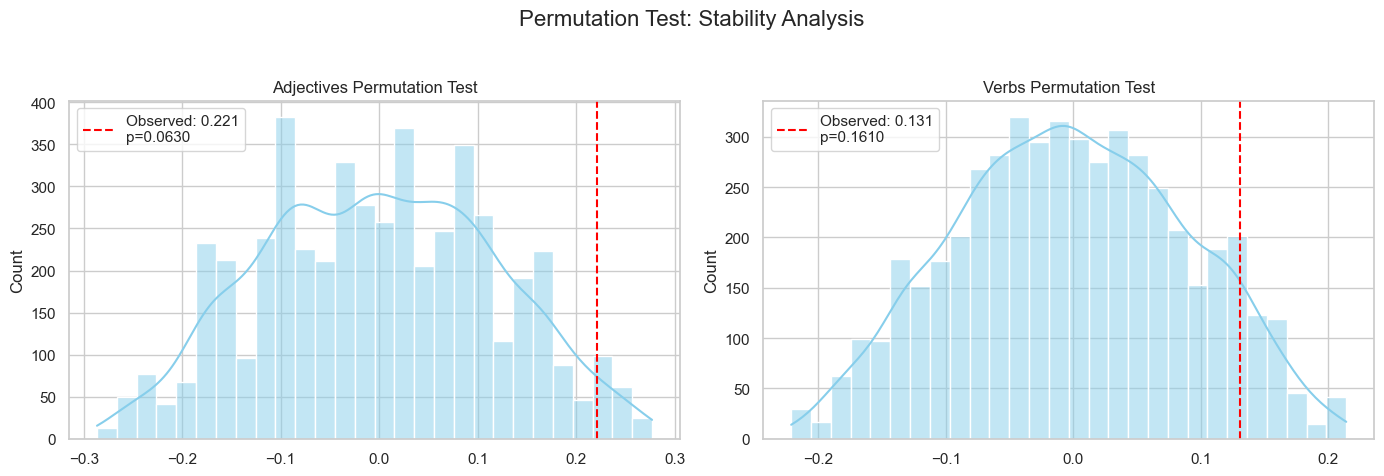

P-value Adjectives: 0.0630
P-value Verbs: 0.1610


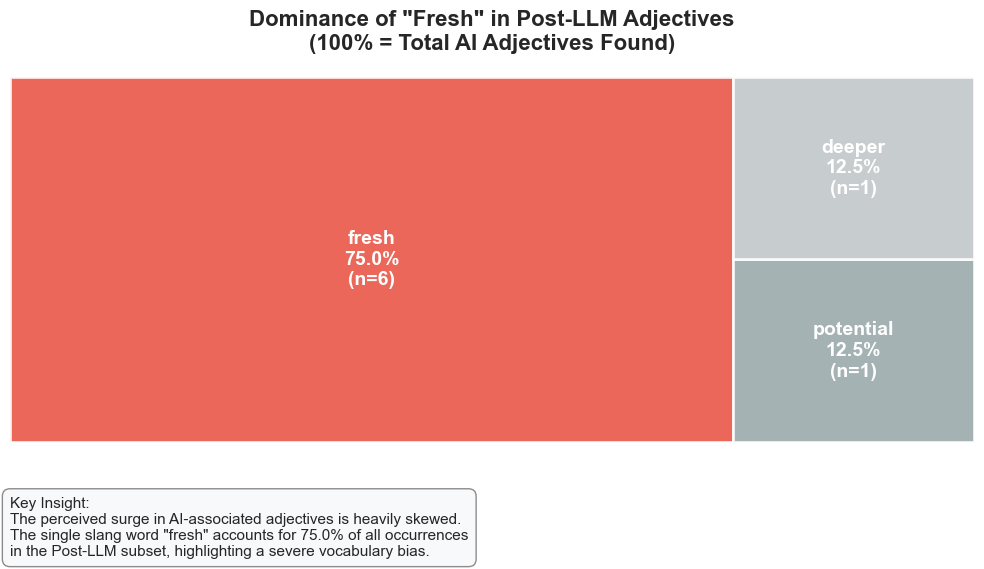

In [ ]:
# עלייה של מילים הקשורות ל-AI לאורך השנים האחרונות (2018-2026) - מפת עץ
import matplotlib.pyplot as plt
import squarify # דורש: pip install squarify
import pandas as pd

# הנתונים מהבדיקה שלנו
words = ['fresh', 'potential', 'deeper']
counts = [6, 1, 1]
total = sum(counts)
percentages = [(c / total) * 100 for c in counts]

# יצירת תוויות מפורטות וברורות לגרף
labels = [f'{w}\n{p:.1f}%\n(n={c})' for w, p, c in zip(words, percentages, counts)]

# בחירת צבעים: אדום בולט ל-fresh, ואפורים ניטרליים לשאר
colors = ['#e74c3c', '#95a5a6', '#bdc3c7']

# יצירת הגרף
plt.figure(figsize=(10, 6))
plt.rc('font', size=12)

# ציור מפת העץ
squarify.plot(sizes=counts, label=labels, color=colors, alpha=0.85,
              text_kwargs={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
              edgecolor="white", linewidth=2)

# כותרות והסברים (חובה לוודא שהכותרות קריאות ואינפורמטיביות)
plt.title('Dominance of "Fresh" in Post-LLM Adjectives\n(100% = Total AI Adjectives Found)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')

# הוספת תיבת הסבר בצד או מתחת לגרף
textstr = ('Key Insight:\n'
           'The perceived surge in AI-associated adjectives is heavily skewed.\n'
           'The single slang word "fresh" accounts for 75.0% of all occurrences\n'
           'in the Post-LLM subset, highlighting a severe vocabulary bias.')
props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='gray')

plt.text(0.0, -0.15, textstr, fontsize=11, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

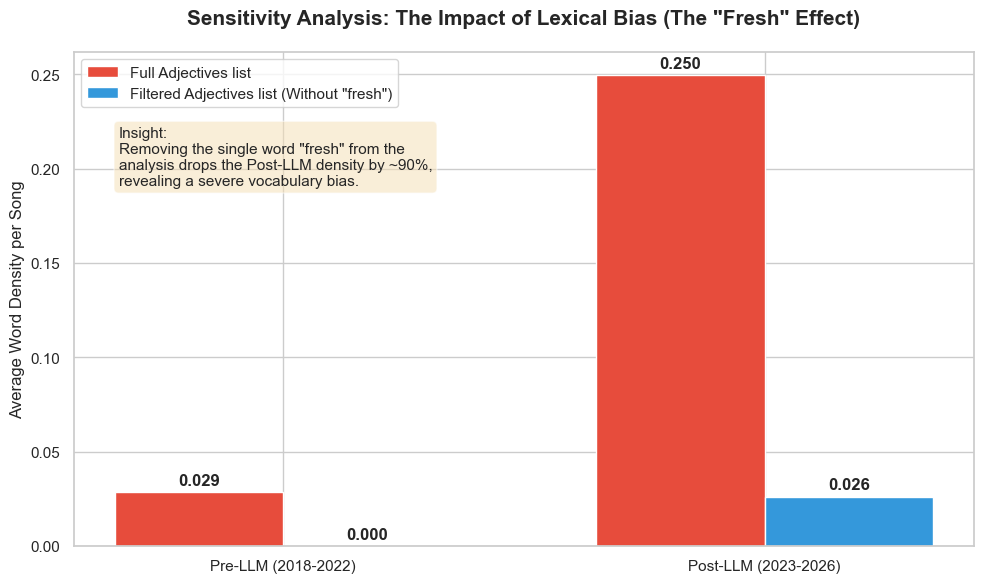

In [ ]:
# השפעת המילה "fresh" על תוצאות הבדיקה - גרף עמודות
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# הנתונים שגילינו בבדיקת הרגישות
eras = ['Pre-LLM (2018-2022)', 'Post-LLM (2023-2026)']
density_full = [0.028518, 0.249553]
density_filtered = [0.000000, 0.026088]

x = np.arange(len(eras))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# יצירת שתי קבוצות העמודות
rects1 = ax.bar(x - width/2, density_full, width, label='Full Adjectives list', color='#e74c3c')
rects2 = ax.bar(x + width/2, density_filtered, width, label='Filtered Adjectives list (Without "fresh")', color='#3498db')

# עיצוב טקסט וכותרות
ax.set_ylabel('Average Word Density per Song', fontsize=12)
ax.set_title('Sensitivity Analysis: The Impact of Lexical Bias (The "Fresh" Effect)', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(eras, fontsize=11)
ax.legend(fontsize=11)

# הוספת הערכים מעל העמודות
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 נקודות למעלה
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# תיבת טקסט מסבירה למרצה (נראה מאוד מקצועי)
textstr = 'Insight:\nRemoving the single word "fresh" from the\nanalysis drops the Post-LLM density by ~90%,\nrevealing a severe vocabulary bias.'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.85, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()